In [1]:
import numpy as np
import matplotlib.pyplot as plt
from expelliarmus import Wizard
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer


def analyze_event_file(
    fpath,
    bin_width_s=0.1,
    window_size=10,
    n_clusters=2,
    save_path=None,
    show=True
):
    """
    Analyze a single event-based recording and generate a single summary figure.

    Parameters
    ----------
    fpath : str
        Path to .dat event file
    bin_width_s : float
        Temporal bin width in seconds (default 100 ms)
    window_size : int
        Number of bins per cycle (default 10 → 1 second)
    n_clusters : int
        Number of KMeans clusters
    save_path : str or None
        If provided, saves the figure to this path
    show : bool
        Whether to display the figure
    """

    # -------------------------
    # Load events
    # -------------------------
    wizard = Wizard(encoding="dat")
    wizard.set_file(fpath)
    events = wizard.read()

    ts = events["t"].astype(np.int64)
    BIN_WIDTH_US = int(bin_width_s * 1e6)

    t0, t1 = ts.min(), ts.max()
    num_bins = (t1 - t0) // BIN_WIDTH_US + 1
    bin_indices = (ts - t0) // BIN_WIDTH_US

    bins = [[] for _ in range(num_bins)]
    for evt, b in zip(events, bin_indices):
        bins[b].append(evt)

    # -------------------------
    # Aggregate per bin
    # -------------------------
    aggregated = []
    for bin_events in bins:
        if len(bin_events) == 0:
            aggregated.append(
                {"count": 0, "mean_x": np.nan, "mean_y": np.nan, "sum_p": 0}
            )
            continue

        xs = np.array([e["x"] for e in bin_events])
        ys = np.array([e["y"] for e in bin_events])
        ps = np.array([e["p"] for e in bin_events])

        aggregated.append(
            {
                "count": len(bin_events),
                "mean_x": xs.mean(),
                "mean_y": ys.mean(),
                "sum_p": ps.sum(),
            }
        )

    trajectory = np.array(
        [[row["mean_x"], row["mean_y"]] for row in aggregated]
    )

    # -------------------------
    # Segment into cycles
    # -------------------------
    num_segments = len(trajectory) // window_size
    segments = np.array(
        [
            trajectory[i * window_size : (i + 1) * window_size]
            for i in range(num_segments)
        ]
    )

    flat_segments = segments.reshape(num_segments, -1)

    # -------------------------
    # Similarity + clustering
    # -------------------------
    similarity_matrix = cosine_similarity(flat_segments)

    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    labels = kmeans.fit_predict(flat_segments)

    silhouette = silhouette_score(flat_segments, labels)

    # -------------------------
    # PCA alignment
    # -------------------------
    aligned_segments = []
    for seg in segments:
        centered = seg - seg.mean(axis=0)
        pca = PCA(n_components=2)
        aligned_segments.append(pca.fit_transform(centered))
    aligned_segments = np.array(aligned_segments)

    # -------------------------
    # Metrics
    # -------------------------
    # Amplitude
    amplitude = []
    for seg in aligned_segments:
        diffs = np.diff(seg, axis=0)
        amplitude.append(np.linalg.norm(diffs, axis=1).sum())
    amplitude = np.array(amplitude)

    # Phase
    normalizer = Normalizer(norm="l2")
    normed = normalizer.fit_transform(flat_segments)
    phase_similarity = normed @ normed[0]
    phase_angle = np.arccos(np.clip(phase_similarity, -1, 1))

    # Temporal drift
    temporal_drift = np.array(
        [normed[i] @ normed[i - 1] for i in range(1, len(normed))]
    )

    # Spatial drift
    centroids = aligned_segments.mean(axis=1)
    centroid_drift = np.linalg.norm(centroids - centroids[0], axis=1)

    mean_seg = aligned_segments.mean(axis=0)
    std_seg = aligned_segments.std(axis=0)
    t = np.arange(window_size)

    # -------------------------
    # Plot everything in ONE figure
    # -------------------------
    fig, axes = plt.subplots(4, 2, figsize=(16, 18))
    fig.suptitle(
        f"Event Motion Analysis\nSilhouette Score = {silhouette:.3f}",
        fontsize=16,
    )

    # 1. Amplitude
    axes[0, 0].plot(amplitude, marker="o")
    axes[0, 0].set_title("Amplitude per Cycle")
    axes[0, 0].grid(True)

    # 2. Phase shift
    axes[0, 1].plot(phase_angle, marker="o", color="purple")
    axes[0, 1].set_title("Phase Shift per Cycle")
    axes[0, 1].grid(True)

    # 3. Centroid XY
    axes[1, 0].plot(centroids[:, 0], centroids[:, 1], marker="o")
    axes[1, 0].set_title("Centroid Trajectory (XY)")
    axes[1, 0].axis("equal")
    axes[1, 0].grid(True)

    # 4. Temporal drift
    axes[1, 1].plot(temporal_drift, marker="o", color="orange")
    axes[1, 1].set_title("Temporal Drift")
    axes[1, 1].grid(True)

    # 5. Similarity matrix
    im = axes[2, 0].imshow(similarity_matrix, cmap="viridis", aspect="auto")
    axes[2, 0].set_title("Cycle Similarity Matrix")
    fig.colorbar(im, ax=axes[2, 0], fraction=0.046)

    # 6. Spatial drift
    axes[2, 1].plot(centroid_drift, marker="o", color="green")
    axes[2, 1].set_title("Spatial Drift from Cycle 0")
    axes[2, 1].grid(True)

    # 7. Mean X motion
    axes[3, 0].plot(t, mean_seg[:, 0])
    axes[3, 0].fill_between(
        t,
        mean_seg[:, 0] - std_seg[:, 0],
        mean_seg[:, 0] + std_seg[:, 0],
        alpha=0.3,
    )
    axes[3, 0].set_title("Mean X Motion ± STD")
    axes[3, 0].grid(True)

    # 8. Mean Y motion
    axes[3, 1].plot(t, mean_seg[:, 1])
    axes[3, 1].fill_between(
        t,
        mean_seg[:, 1] - std_seg[:, 1],
        mean_seg[:, 1] + std_seg[:, 1],
        alpha=0.3,
    )
    axes[3, 1].set_title("Mean Y Motion ± STD")
    axes[3, 1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        plt.savefig(save_path, dpi=200)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "silhouette": silhouette,
        "amplitude_mean": amplitude.mean(),
        "amplitude_std": amplitude.std(),
        "phase_mean": phase_angle.mean(),
        "phase_std": phase_angle.std(),
        "spatial_drift_final": centroid_drift[-1],
        "temporal_drift_mean": temporal_drift.mean(),
        "temporal_drift_std": temporal_drift.std(),
    }

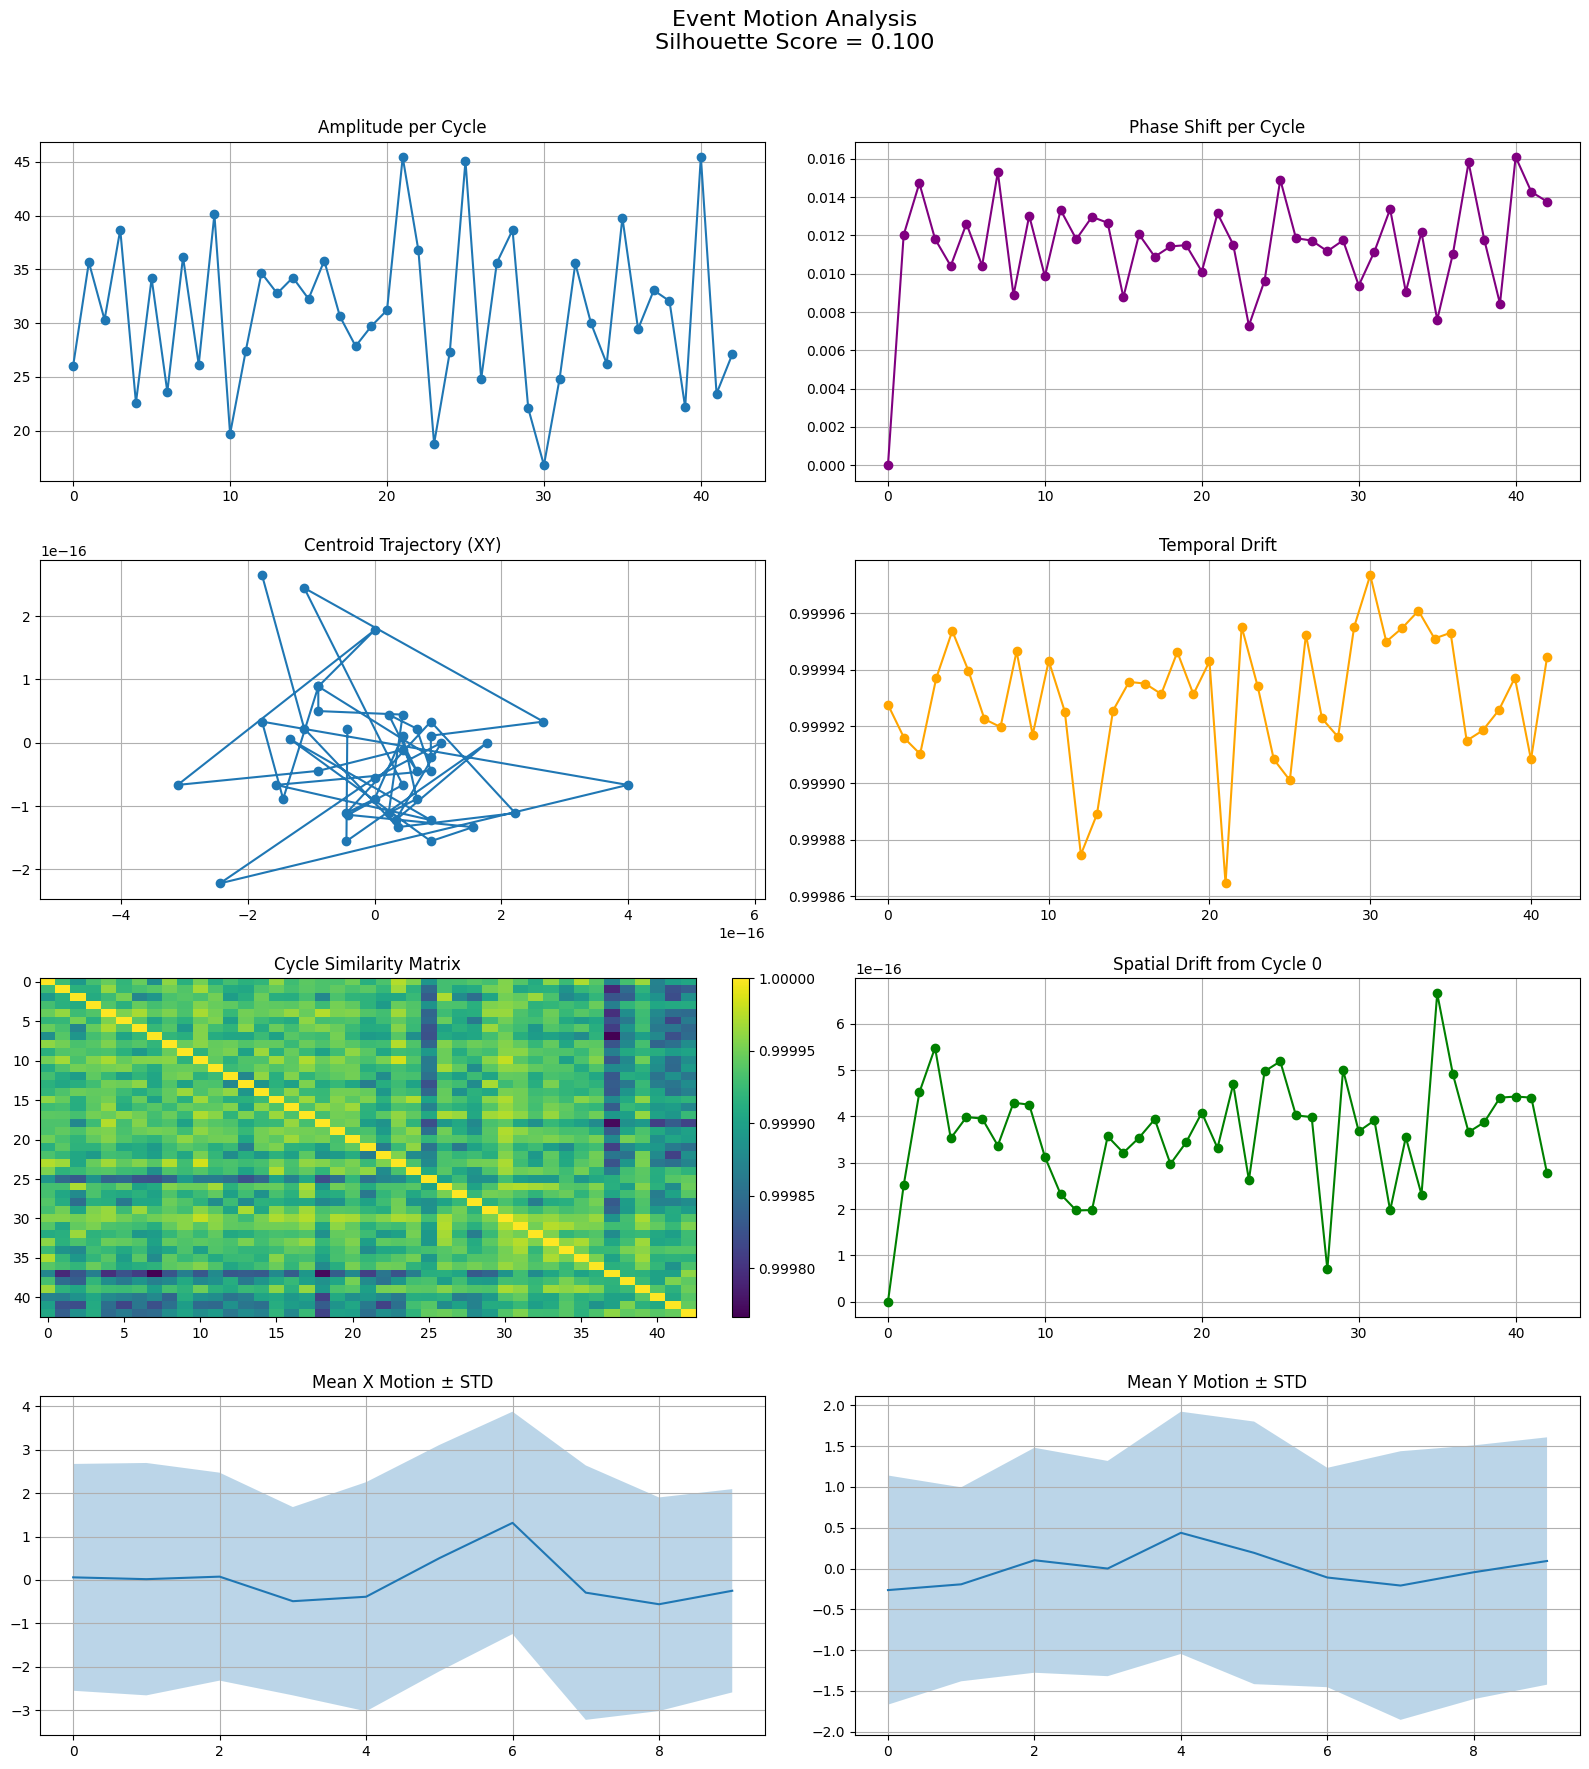

In [2]:
results = analyze_event_file(
    "/data/tracking/PalmBackLaserON_01_cd.dat",
    save_path="/data/tracking/PalmBackLaserON_summary.png"
)

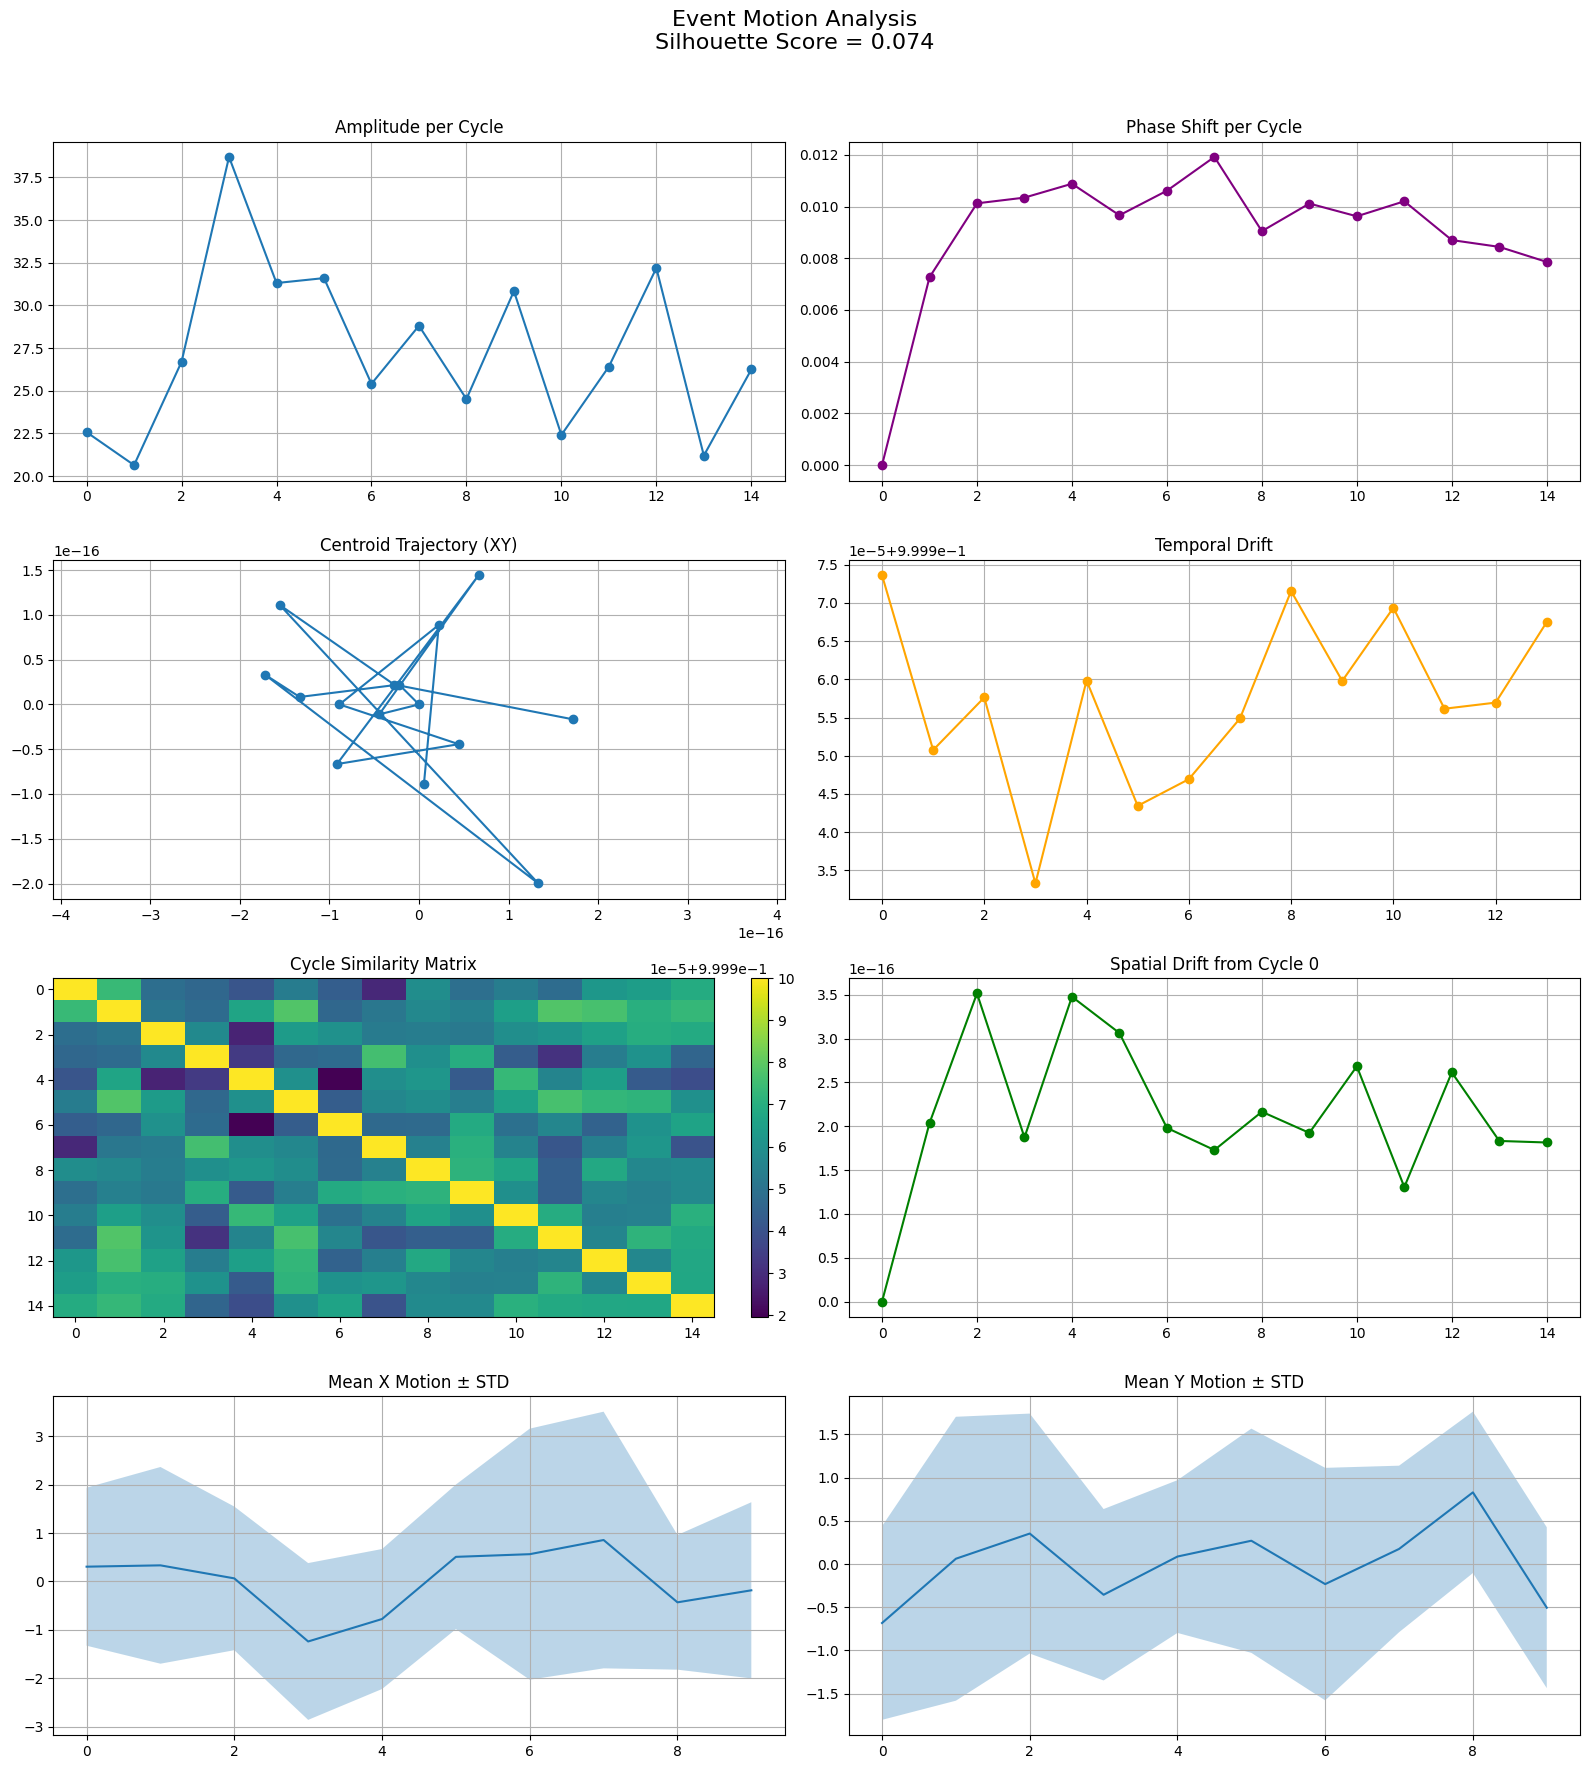

In [3]:

results = analyze_event_file(
    "/data/tracking/PalmBackLaserOFF_01_cd.dat",
    save_path="/data/tracking/PalmBackLaserOFF_summary.png"
)

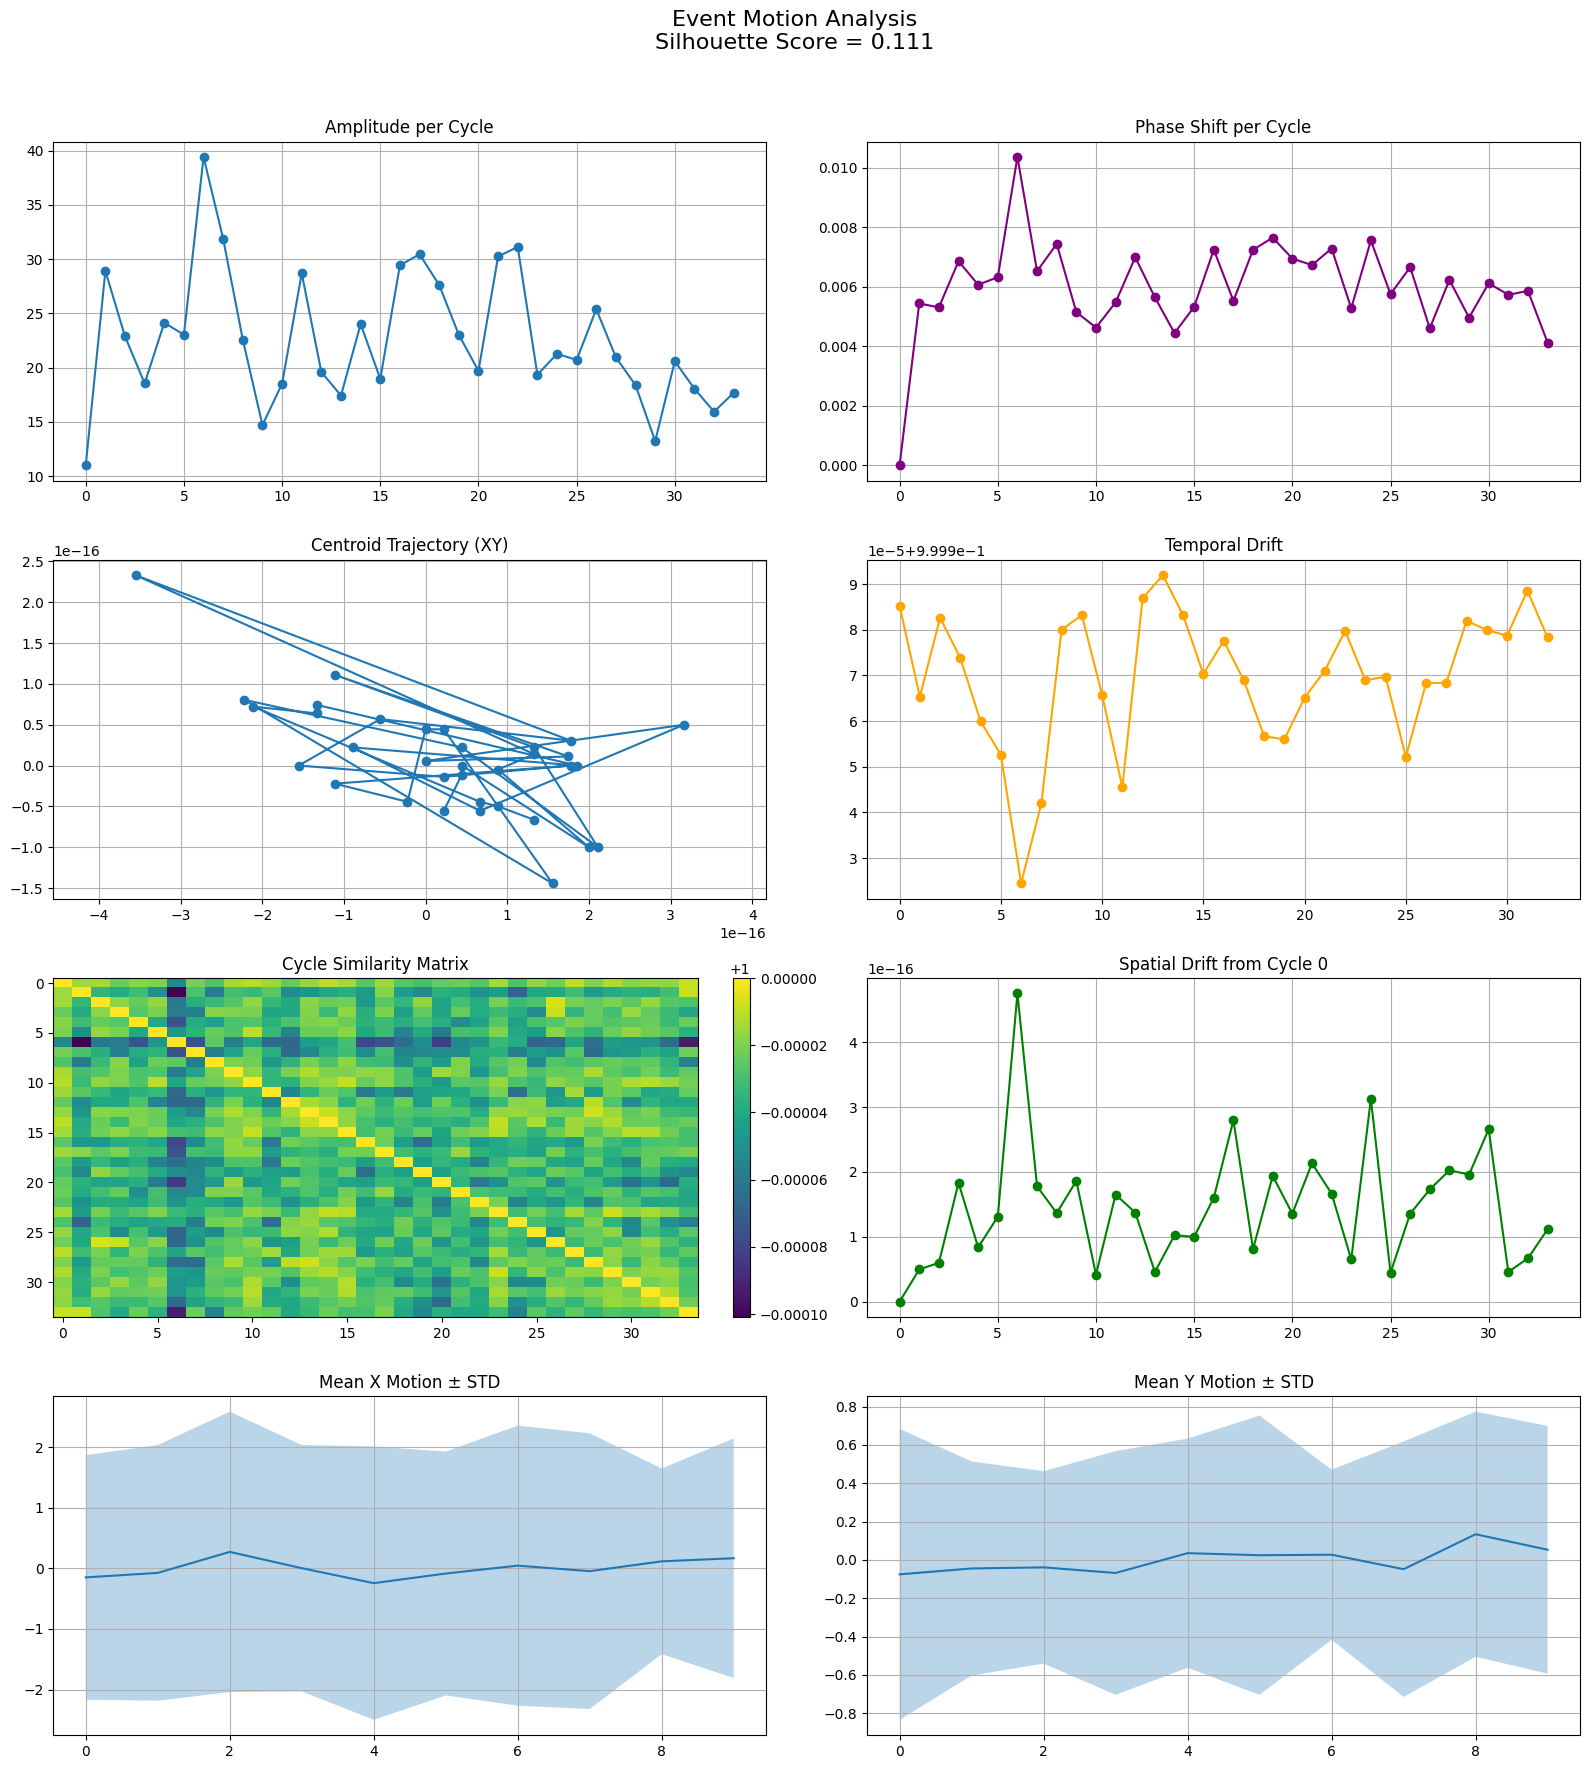

In [4]:
results = analyze_event_file(
    "/data/tracking/PalmLaserON_01_cd.dat",
    save_path="/data/tracking/PalmLaserON_summary.png"
)
